# JP Morgan Quant V3 — Dual Attention Transformer

V2 → V3 升级：
1. Dual Attention (Temporal + Cross-Sectional)
2. Time2Vec positional encoding
3. ~800K params (10x V2)
4. 30+ factors (含基本面)
5. Combined Loss (Rank + MSE + IC)
6. 数据本地缓存

## 0. 依赖

In [19]:
!pip install yfinance -q

In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
import os, pickle, copy
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## 1. 下载数据（首次运行）

In [21]:
STOCK_UNIVERSE = [
    'AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA',
    'AVGO','ORCL','CRM','ADBE','AMD','INTC','CSCO','IBM',
    'QCOM','TXN','MU','AMAT','LRCX','KLAC','MRVL','ON',
    'NOW','PANW','SNOW','PLTR','NET','DDOG','ZS','CRWD',
    'NFLX','PYPL','SQ','SHOP','UBER','ABNB','SNAP','PINS',
    'XOM','CVX','COP','EOG','SLB','MPC','PSX','VLO',
    'OXY','DVN','HES','HAL','BKR','FANG',
    'ENPH','SEDG','FSLR','NEE','AES','CEG','VST',
    'JPM','GS','UNH','JNJ','PG'
]

MARKET_TICKERS = {'SPY':'SP500','QQQ':'Nasdaq100','XLE':'EnergySector','TLT':'Bond20Y','GLD':'Gold'}
START_DATE = '2016-01-01'
END_DATE = '2025-12-31'
SAVE_DIR = './v3_data'

def download_all():
    print('下载股票数据...')
    raw = {}
    for t in STOCK_UNIVERSE:
        try:
            df = yf.download(t, start=START_DATE, end=END_DATE, progress=False)
            if len(df) > 200:
                raw[t] = df
                print(f'  ✓ {t}: {len(df)}')
        except: print(f'  ✗ {t}')
    
    print('\n下载市场基准...')
    mkt = {}
    for t, name in MARKET_TICKERS.items():
        try:
            df = yf.download(t, start=START_DATE, end=END_DATE, progress=False)
            if len(df) > 200:
                mkt[name] = df['Close'].values.flatten()
                mkt[f'{name}_idx'] = df.index
                print(f'  ✓ {name}')
        except: print(f'  ✗ {name}')
    
    print('\n获取基本面...')
    fund = {}
    for t in raw.keys():
        try:
            info = yf.Ticker(t).info
            fund[t] = {
                'pe': info.get('trailingPE', np.nan),
                'pb': info.get('priceToBook', np.nan),
                'market_cap': info.get('marketCap', np.nan),
                'dividend_yield': info.get('dividendYield', 0) or 0,
                'roe': info.get('returnOnEquity', np.nan),
            }
            print(f'  ✓ {t}')
        except:
            fund[t] = {}
            print(f'  ✗ {t}')
    
    return raw, mkt, fund

def save_data(raw, mkt, fund):
    os.makedirs(SAVE_DIR, exist_ok=True)
    for t, df in raw.items():
        # 确保保存前列名是干净的
        df_save = df.copy()
        df_save.columns = [str(c).split(',')[0].strip().strip("('\"") for c in df_save.columns]
        df_save.to_csv(os.path.join(SAVE_DIR, f'{t}.csv'))
    with open(os.path.join(SAVE_DIR, 'market.pkl'), 'wb') as f:
        pickle.dump(mkt, f)
    with open(os.path.join(SAVE_DIR, 'fund.pkl'), 'wb') as f:
        pickle.dump(fund, f)
    
    print(f'✅ 保存到 {SAVE_DIR}/ ({len(raw)} stocks)')

def load_data():
    raw = {}
    for fname in os.listdir(SAVE_DIR):
        if fname.endswith('.csv'):
            t = fname.replace('.csv', '')
            raw[t] = pd.read_csv(os.path.join(SAVE_DIR, fname), index_col=0, parse_dates=True)
    with open(os.path.join(SAVE_DIR, 'market.pkl'), 'rb') as f:
        mkt = pickle.load(f)
    with open(os.path.join(SAVE_DIR, 'fund.pkl'), 'rb') as f:
        fund = pickle.load(f)
    print(f'✅ 从 {SAVE_DIR}/ 加载 ({len(raw)} stocks)')
    return raw, mkt, fund

# 首次下载并保存；之后改成 load_data()
if os.path.exists(os.path.join(SAVE_DIR, 'market.pkl')):
    raw_data, market_data, fundamentals = load_data()
else:
    raw_data, market_data, fundamentals = download_all()
    save_data(raw_data, market_data, fundamentals)

下载股票数据...


  ✓ AAPL: 2513
  ✓ MSFT: 2513
  ✓ GOOGL: 2513
  ✓ AMZN: 2513
  ✓ META: 2513
  ✓ NVDA: 2513
  ✓ TSLA: 2513
  ✓ AVGO: 2513
  ✓ ORCL: 2513
  ✓ CRM: 2513
  ✓ ADBE: 2513
  ✓ AMD: 2513
  ✓ INTC: 2513
  ✓ CSCO: 2513
  ✓ IBM: 2513
  ✓ QCOM: 2513
  ✓ TXN: 2513
  ✓ MU: 2513
  ✓ AMAT: 2513
  ✓ LRCX: 2513
  ✓ KLAC: 2513
  ✓ MRVL: 2513
  ✓ ON: 2513
  ✓ NOW: 2513
  ✓ PANW: 2513
  ✓ SNOW: 1329
  ✓ PLTR: 1319
  ✓ NET: 1583
  ✓ DDOG: 1579
  ✓ ZS: 1959
  ✓ CRWD: 1648
  ✓ NFLX: 2513
  ✓ PYPL: 2513


$SQ: possibly delisted; no timezone found

1 Failed download:
['SQ']: possibly delisted; no timezone found


  ✓ SHOP: 2513
  ✓ UBER: 1670
  ✓ ABNB: 1269
  ✓ SNAP: 2221
  ✓ PINS: 1685
  ✓ XOM: 2513
  ✓ CVX: 2513
  ✓ COP: 2513
  ✓ EOG: 2513
  ✓ SLB: 2513
  ✓ MPC: 2513
  ✓ PSX: 2513
  ✓ VLO: 2513
  ✓ OXY: 2513
  ✓ DVN: 2513


$HES: possibly delisted; no timezone found

1 Failed download:
['HES']: possibly delisted; no timezone found


  ✓ HAL: 2513
  ✓ BKR: 2513
  ✓ FANG: 2513
  ✓ ENPH: 2513
  ✓ SEDG: 2513
  ✓ FSLR: 2513
  ✓ NEE: 2513
  ✓ AES: 2513
  ✓ CEG: 991
  ✓ VST: 2322
  ✓ JPM: 2513
  ✓ GS: 2513
  ✓ UNH: 2513
  ✓ JNJ: 2513
  ✓ PG: 2513

下载市场基准...
  ✓ SP500
  ✓ Nasdaq100
  ✓ EnergySector
  ✓ Bond20Y
  ✓ Gold

获取基本面...
  ✓ AAPL
  ✓ MSFT
  ✓ GOOGL
  ✓ AMZN
  ✓ META
  ✓ NVDA
  ✓ TSLA
  ✓ AVGO
  ✓ ORCL
  ✓ CRM
  ✓ ADBE
  ✓ AMD
  ✓ INTC
  ✓ CSCO
  ✓ IBM
  ✓ QCOM
  ✓ TXN
  ✓ MU
  ✓ AMAT
  ✓ LRCX
  ✓ KLAC
  ✓ MRVL
  ✓ ON
  ✓ NOW
  ✓ PANW
  ✓ SNOW
  ✓ PLTR
  ✓ NET
  ✓ DDOG
  ✓ ZS
  ✓ CRWD
  ✓ NFLX
  ✓ PYPL
  ✓ SHOP
  ✓ UBER
  ✓ ABNB
  ✓ SNAP
  ✓ PINS
  ✓ XOM
  ✓ CVX
  ✓ COP
  ✓ EOG
  ✓ SLB
  ✓ MPC
  ✓ PSX
  ✓ VLO
  ✓ OXY
  ✓ DVN
  ✓ HAL
  ✓ BKR
  ✓ FANG
  ✓ ENPH
  ✓ SEDG
  ✓ FSLR
  ✓ NEE
  ✓ AES
  ✓ CEG
  ✓ VST
  ✓ JPM
  ✓ GS
  ✓ UNH
  ✓ JNJ
  ✓ PG
✅ 保存到 ./v3_data/ (63 stocks)


## 2. V3 因子工程（~30 factors）

In [22]:
def compute_v3_factors(df, market_data, fund_data=None):
    f = pd.DataFrame(index=df.index)
    c = pd.Series(df['Close'].values.flatten(), index=df.index)
    v = pd.Series(df['Volume'].values.flatten(), index=df.index)
    h = pd.Series(df['High'].values.flatten(), index=df.index)
    l = pd.Series(df['Low'].values.flatten(), index=df.index)
    o = pd.Series(df['Open'].values.flatten(), index=df.index)
    dr = c.pct_change()

    for n in [5,10,20,60]: f[f'ret_{n}d'] = c.pct_change(n)
    f['mom_accel'] = f['ret_5d'] - f['ret_5d'].shift(5)

    f['vol_20d'] = dr.rolling(20).std()
    f['vol_ratio'] = dr.rolling(5).std() / dr.rolling(20).std()
    f['vol_accel'] = f['vol_20d'].pct_change(5)
    f['intraday_vol'] = ((h - l) / c).rolling(20).mean()
    f['vol_spread'] = f['intraday_vol'] - f['vol_20d']

    f['vol_ma_ratio'] = v / v.rolling(20).mean()
    f['volume_trend'] = v.rolling(5).mean() / v.rolling(20).mean() - 1
    obv = (dr.apply(np.sign) * v).rolling(20).sum()
    f['obv_norm'] = obv / v.rolling(20).sum()
    vwap = (c * v).rolling(20).sum() / v.rolling(20).sum()
    f['vwap_dev'] = c / vwap - 1

    f['bb_pos'] = (c - c.rolling(20).mean()) / (c.rolling(20).std() * 2)
    f['ma_cross_s'] = c.rolling(5).mean() / c.rolling(20).mean() - 1
    f['ma_cross_l'] = c.rolling(20).mean() / c.rolling(60).mean() - 1

    delta = c.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss_v = (-delta.where(delta < 0, 0)).rolling(14).mean()
    f['rsi'] = (100 - 100 / (1 + gain / loss_v.replace(0, np.nan))) / 100 - 0.5

    rmin, rmax = c.rolling(60).min(), c.rolling(60).max()
    f['price_pos'] = ((c - rmin) / (rmax - rmin).replace(0, np.nan)) - 0.5
    f['price_range'] = (h - l) / c

    for name in ['SP500','Nasdaq100','EnergySector']:
        if name in market_data:
            ref = pd.Series(market_data[name], index=market_data[f'{name}_idx'])
            ref_a = ref.reindex(df.index, method='ffill')
            f[f'rel_{name}'] = c.pct_change(20) - ref_a.pct_change(20)
            f[f'corr_{name}'] = dr.rolling(60).corr(ref_a.pct_change())

    f['ret_252d'] = c.pct_change(252)
    f['ma200_dev'] = c / c.rolling(200).mean() - 1
    f['sharpe_20d'] = f['ret_20d'] / f['vol_20d'].replace(0, np.nan)
    f['gap'] = (o / c.shift(1) - 1).rolling(5).mean()

    if fund_data:
        for k in ['pe','pb','market_cap','dividend_yield','roe']:
            val = fund_data.get(k, np.nan)
            f[f'f_{k}'] = val if (not np.isnan(val) if isinstance(val, float) else True) else 0.0

    return f.dropna()

sample = compute_v3_factors(raw_data[list(raw_data.keys())[0]], market_data, fundamentals.get(list(raw_data.keys())[0], {}))
print(f'因子数: {sample.shape[1]}')
print(list(sample.columns))

因子数: 35
['ret_5d', 'ret_10d', 'ret_20d', 'ret_60d', 'mom_accel', 'vol_20d', 'vol_ratio', 'vol_accel', 'intraday_vol', 'vol_spread', 'vol_ma_ratio', 'volume_trend', 'obv_norm', 'vwap_dev', 'bb_pos', 'ma_cross_s', 'ma_cross_l', 'rsi', 'price_pos', 'price_range', 'rel_SP500', 'corr_SP500', 'rel_Nasdaq100', 'corr_Nasdaq100', 'rel_EnergySector', 'corr_EnergySector', 'ret_252d', 'ma200_dev', 'sharpe_20d', 'gap', 'f_pe', 'f_pb', 'f_market_cap', 'f_dividend_yield', 'f_roe']


## 3. 数据集（滚动标准化 + 日期对齐）

In [23]:
LOOKBACK = 20
SCALER_WINDOW = 120

def prepare_dataset(raw_data, market_data, fundamentals, lookback=20, scaler_window=120, train_ratio=0.70):
    all_stock = {}
    for t, df in raw_data.items():
        fac = compute_v3_factors(df, market_data, fundamentals.get(t, {}))
        cs = pd.Series(df['Close'].values.flatten(), index=df.index)
        fut = cs.pct_change(5).shift(-5)
        idx = fac.index.intersection(fut.dropna().index)
        all_stock[t] = {'factors': fac.loc[idx], 'target': fut.loc[idx]}

    nf = list(all_stock.values())[0]['factors'].shape[1]

    all_dates = None
    for d in all_stock.values():
        s = set(d['factors'].index)
        all_dates = s if all_dates is None else all_dates.intersection(s)
    all_dates = sorted(list(all_dates))
    print(f'共有交易日: {len(all_dates)}')

    X, y, tks, dts = [], [], [], []
    for t, d in all_stock.items():
        fdf = d['factors'].loc[d['factors'].index.isin(all_dates)]
        tgt = d['target'].loc[d['target'].index.isin(all_dates)]
        fn, tn, dl = fdf.values, tgt.values, fdf.index.tolist()
        for i in range(max(scaler_window, lookback), len(fn)):
            w = fn[max(0, i-scaler_window):i]
            mu, sd = np.nanmean(w, axis=0), np.nanstd(w, axis=0)
            sd[sd < 1e-8] = 1.0
            s = (fn[i-lookback:i] - mu) / sd
            if np.any(np.isnan(s)) or np.isnan(tn[i]): continue
            X.append(s.astype(np.float32)); y.append(tn[i]); tks.append(t); dts.append(dl[i])

    X, y = np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
    ud = sorted(set(dts))
    sp = ud[int(len(ud) * train_ratio)]
    tr = np.array([d < sp for d in dts])
    te = ~tr

    print(f'Split: {sp.strftime("%Y-%m-%d")} | Train: {tr.sum()} | Test: {te.sum()}')
    tc = pd.Series([d for d, m in zip(dts, te) if m]).value_counts()
    print(f'测试集每天股票数: min={tc.min()}, max={tc.max()}')

    return {
        'X_train': X[tr], 'y_train': y[tr],
        'tickers_train': [t for t, m in zip(tks, tr) if m],
        'dates_train': [d for d, m in zip(dts, tr) if m],
        'X_test': X[te], 'y_test': y[te],
        'tickers_test': [t for t, m in zip(tks, te) if m],
        'dates_test': [d for d, m in zip(dts, te) if m],
        'num_factors': nf
    }

dataset = prepare_dataset(raw_data, market_data, fundamentals)
NUM_FACTORS = dataset['num_factors']

class SDS(Dataset):
    def __init__(self, X, y): self.X, self.y = torch.FloatTensor(X), torch.FloatTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = SDS(dataset['X_train'], dataset['y_train'])
test_ds = SDS(dataset['X_test'], dataset['y_test'])
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True)
print(f'Train batches: {len(train_loader)} | Sample: {train_ds[0][0].shape}')

共有交易日: 724
Split: 2025-04-02 | Train: 26586 | Test: 11466
测试集每天股票数: min=63, max=63
Train batches: 103 | Sample: torch.Size([20, 35])


## 4. V3 Model

In [24]:
class Time2Vec(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.lin = nn.Linear(1, 1)
        self.per = nn.Linear(1, d - 1)
    def forward(self, T, dev):
        t = (torch.arange(T, dtype=torch.float32, device=dev) / T).unsqueeze(-1)
        return torch.cat([self.lin(t), torch.sin(self.per(t))], dim=-1)

class DualBlock(nn.Module):
    def __init__(self, d, nh, ff, drop):
        super().__init__()
        self.temp = nn.TransformerEncoderLayer(d_model=d, nhead=nh, dim_feedforward=ff, dropout=drop, batch_first=True, norm_first=True)
        self.gate = nn.Sequential(nn.Linear(d, d), nn.GELU(), nn.Linear(d, d), nn.Sigmoid())
        self.norm = nn.LayerNorm(d)
    def forward(self, x):
        x = self.temp(x)
        g = self.gate(x.mean(dim=0, keepdim=True))
        return self.norm(x * g + x)

class QuantV3(nn.Module):
    def __init__(self, nf, d=192, nh=6, nl=4, ff=384, drop=0.15):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(nf, d), nn.LayerNorm(d), nn.GELU(), nn.Dropout(drop))
        self.t2v = Time2Vec(d)
        self.blocks = nn.ModuleList([DualBlock(d, nh, ff, drop) for _ in range(nl)])
        self.pool = nn.Sequential(nn.Linear(d, d//4), nn.Tanh(), nn.Linear(d//4, 1))
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Linear(d, d//2), nn.GELU(), nn.Dropout(drop), nn.Linear(d//2, d//4), nn.GELU(), nn.Dropout(drop*0.5), nn.Linear(d//4, 1))
        self.apply(self._iw)
    def _iw(self, m):
        if isinstance(m, nn.Linear): nn.init.xavier_normal_(m.weight); (m.bias is not None) and nn.init.zeros_(m.bias)
    def forward(self, x):
        B, T, _ = x.shape
        x = self.proj(x) + self.t2v(T, x.device).unsqueeze(0)
        for b in self.blocks: x = b(x)
        w = torch.softmax(self.pool(x), dim=1)
        return self.head((x * w).sum(dim=1))

model = QuantV3(nf=NUM_FACTORS, d=192, nh=6, nl=4, ff=384, drop=0.15).to(device)
print(f'V3 params: {sum(p.numel() for p in model.parameters()):,}')

V3 params: 1,526,690


## 5. Combined Loss (Rank + MSE + IC)

In [25]:
class CombinedLoss(nn.Module):
    def __init__(self, rw=0.5, mw=0.2, iw=0.3, margin=0.001):
        super().__init__()
        self.rw, self.mw, self.iw, self.margin = rw, mw, iw, margin
        self.mse = nn.MSELoss()
    def forward(self, pred, target):
        p, t = pred.squeeze(), target.squeeze()
        n = len(p)
        if n < 4: return self.mse(p, t), 0., self.mse(p,t).item(), 0.
        np_ = min(n*4, 512)
        ii, jj = torch.randint(0,n,(np_,),device=p.device), torch.randint(0,n,(np_,),device=p.device)
        rl = torch.clamp(self.margin - torch.sign(t[ii]-t[jj]) * (p[ii]-p[jj]), min=0).mean()
        ml = self.mse(p, t)
        pm, tm = p - p.mean(), t - t.mean()
        ic = (pm * tm).mean() / ((pm.std()+1e-8) * (tm.std()+1e-8))
        total = self.rw * rl + self.mw * ml + self.iw * (1 - ic)
        return total, rl.item(), ml.item(), ic.item()

criterion = CombinedLoss()
print('Loss: 50% Rank + 20% MSE + 30% IC')

Loss: 50% Rank + 20% MSE + 30% IC


## 6. 训练（CosineAnnealingLR T_max=40, 80 epochs）

In [26]:
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
NUM_EPOCHS = 80
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

hist = {'total':[], 'rank':[], 'mse':[], 'ic':[]}
print(f'Training {NUM_EPOCHS} epochs (CosineAnnealingLR T_max=40 → 2 cycles)\n')

for ep in range(NUM_EPOCHS):
    model.train()
    et, er, em, ei, nb = 0,0,0,0,0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss, rl, ml, ic = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        et+=loss.item(); er+=rl; em+=ml; ei+=ic; nb+=1
    scheduler.step()
    hist['total'].append(et/nb); hist['rank'].append(er/nb); hist['mse'].append(em/nb); hist['ic'].append(ei/nb)
    if (ep+1)%10==0:
        print(f'Epoch {ep+1:3d}/{NUM_EPOCHS} | Total:{et/nb:.5f} | Rank:{er/nb:.5f} | MSE:{em/nb:.5f} | IC:{ei/nb:.4f} | LR:{optimizer.param_groups[0]["lr"]:.2e}')

print('\nDone!')

Training 80 epochs (CosineAnnealingLR T_max=40 → 2 cycles)

Epoch  10/80 | Total:0.09582 | Rank:0.00729 | MSE:0.00190 | IC:0.6940 | LR:2.56e-04
Epoch  20/80 | Total:0.06224 | Rank:0.00399 | MSE:0.00135 | IC:0.8001 | LR:1.50e-04
Epoch  30/80 | Total:0.04972 | Rank:0.00298 | MSE:0.00127 | IC:0.8401 | LR:4.39e-05
Epoch  40/80 | Total:0.04679 | Rank:0.00268 | MSE:0.00130 | IC:0.8494 | LR:0.00e+00
Epoch  50/80 | Total:0.04730 | Rank:0.00274 | MSE:0.00128 | IC:0.8478 | LR:4.39e-05
Epoch  60/80 | Total:0.04878 | Rank:0.00305 | MSE:0.00122 | IC:0.8433 | LR:1.50e-04
Epoch  70/80 | Total:0.04680 | Rank:0.00304 | MSE:0.00114 | IC:0.8498 | LR:2.56e-04
Epoch  80/80 | Total:0.04123 | Rank:0.00248 | MSE:0.00121 | IC:0.8675 | LR:3.00e-04

Done!


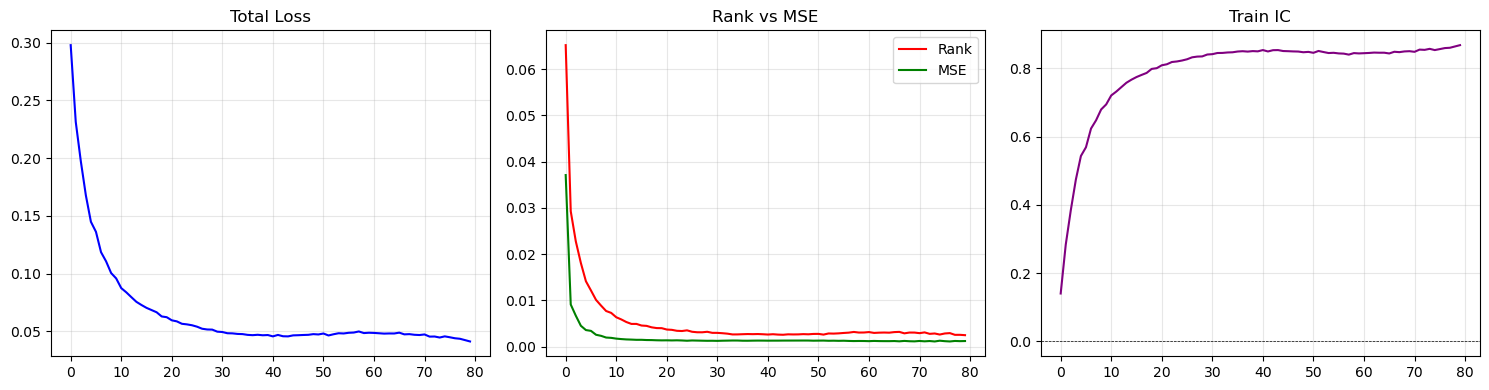

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist['total'],'b-'); axes[0].set_title('Total Loss'); axes[0].grid(True,alpha=0.3)
axes[1].plot(hist['rank'],'r-',label='Rank'); axes[1].plot(hist['mse'],'g-',label='MSE')
axes[1].legend(); axes[1].set_title('Rank vs MSE'); axes[1].grid(True,alpha=0.3)
axes[2].plot(hist['ic'],'purple'); axes[2].axhline(y=0,color='k',ls='--',lw=0.5)
axes[2].set_title('Train IC'); axes[2].grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

## 7. 回测（含交易成本 + 信号方向检测）

加入空仓判断，是否面对极度市场波动情况

In [ ]:
# =============================================================================
# 替换 Cell 7: 加入 Regime 检测 + 动态风控的回测
# =============================================================================

TX_COST = 0.001
REBAL_FREQ = 5
TOP_N = 3

def get_vix_proxy(market_data, raw_data):
    """
    用 SPY 的已实现波动率作为 VIX 的代理
    （因为 yfinance 下载 ^VIX 经常失败）
    """
    if 'SP500' in market_data:
        spy = pd.Series(market_data['SP500'], index=market_data['SP500_idx'])
        vol = spy.pct_change().rolling(20).std() * np.sqrt(252) * 100  # 年化波动率 %
        return vol
    # 备选：用股票池的平均波动率
    vols = []
    for t, df in raw_data.items():
        c = pd.Series(df['Close'].values.flatten(), index=df.index)
        vols.append(c.pct_change().rolling(20).std() * np.sqrt(252) * 100)
    return pd.concat(vols, axis=1).mean(axis=1)

# 计算波动率指标
vol_index = get_vix_proxy(market_data, raw_data)
print(f"Vol index range: {vol_index.min():.1f}% ~ {vol_index.max():.1f}%")
print(f"Vol index mean:  {vol_index.mean():.1f}%")


def backtest_with_regime(model, ds, top_n=TOP_N, tx=TX_COST, rf=REBAL_FREQ, rev=False):
    """
    V3+ 回测：加入 Regime 检测和动态风控
    
    Regime 规则（基于已实现波动率，模拟 VIX）：
      vol < 18%  → 正常市场 → 满仓交易
      18% ≤ vol < 28% → 高波动 → 仓位减半
      vol ≥ 28% → 危机模式 → 停止交易（空仓）
    
    动态风控：
      如果连续 2 次交易亏损 → 下一次仓位减半
      如果累计回撤 > 10% → 停止交易直到回撤恢复到 5% 以内
    """
    model.eval()
    xt = torch.FloatTensor(ds['X_test']).to(device)
    
    preds = []
    with torch.no_grad():
        for i in range(0, len(xt), 256):
            p = model(xt[i:i+256]).squeeze().cpu().numpy()
            if p.ndim == 0: p = np.array([p])
            preds.extend(p.tolist())
    
    res = pd.DataFrame({
        'ticker': ds['tickers_test'], 'date': ds['dates_test'],
        'predicted': preds, 'actual': ds['y_test']
    })
    if rev: res['predicted'] = -res['predicted']
    
    dg = res.groupby('date')
    rd = sorted(res['date'].unique())[::rf]
    
    rows = []
    pl, ps = set(), set()
    consecutive_losses = 0
    peak_value = 1.0
    current_value = 1.0
    
    for dt in rd:
        if dt not in dg.groups: continue
        g = dg.get_group(dt)
        if len(g) < 2 * top_n: continue
        
        # === Regime 检测 ===
        vol_at_date = vol_index.reindex([dt], method='ffill')
        if len(vol_at_date) > 0 and not vol_at_date.isna().all():
            current_vol = vol_at_date.values[0]
        else:
            current_vol = 15.0  # 默认正常
        
        if current_vol >= 28:
            regime = 'crisis'
            position_scale = 0.0    # 完全空仓
        elif current_vol >= 18:
            regime = 'high_vol'
            position_scale = 0.5    # 仓位减半
        else:
            regime = 'normal'
            position_scale = 1.0    # 满仓
        
        # === 动态风控 ===
        # 连续亏损 → 减仓
        if consecutive_losses >= 2:
            position_scale *= 0.5
        
        # 最大回撤保护
        drawdown = (current_value - peak_value) / peak_value
        if drawdown < -0.10:
            position_scale = 0.0  # 回撤超 10% → 停止交易
        elif drawdown < -0.05:
            position_scale *= 0.5  # 回撤 5-10% → 减半
        
        # 如果完全空仓，跳过
        if position_scale == 0:
            rows.append({
                'date': dt, 'long_return': 0, 'short_return': 0,
                'gross_return': 0, 'net_return': 0,
                'turnover': 0, 'cost': 0,
                'regime': regime, 'vol': current_vol,
                'position_scale': 0, 'drawdown': drawdown
            })
            continue
        
        # === 正常选股 ===
        g = g.sort_values('predicted', ascending=False)
        lt, st = set(g.head(top_n)['ticker']), set(g.tail(top_n)['ticker'])
        lr = g.head(top_n)['actual'].mean()
        sr = -g.tail(top_n)['actual'].mean()
        
        to = (len(lt - pl) + len(st - ps)) / (2 * top_n)
        cost = to * tx * 2
        
        # 按 position_scale 缩放收益和成本
        gross = (lr + sr) / 2 * position_scale
        net = gross - cost * position_scale
        
        # 更新风控状态
        if net < 0:
            consecutive_losses += 1
        else:
            consecutive_losses = 0
        
        current_value *= (1 + net)
        peak_value = max(peak_value, current_value)
        drawdown = (current_value - peak_value) / peak_value
        
        rows.append({
            'date': dt, 'long_return': lr * position_scale,
            'short_return': sr * position_scale,
            'gross_return': gross, 'net_return': net,
            'turnover': to, 'cost': cost * position_scale,
            'regime': regime, 'vol': current_vol,
            'position_scale': position_scale, 'drawdown': drawdown
        })
        pl, ps = lt, st
    
    bt = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
    return bt, res


# === 运行对比：有/无风控 ===
print("=" * 55)
print("对比：无风控 vs 有风控\n")

# 无风控（原版）
def backtest_original(model, ds, top_n=TOP_N, tx=TX_COST, rf=REBAL_FREQ, rev=False):
    model.eval()
    xt = torch.FloatTensor(ds['X_test']).to(device)
    preds = []
    with torch.no_grad():
        for i in range(0, len(xt), 256):
            p = model(xt[i:i+256]).squeeze().cpu().numpy()
            if p.ndim == 0: p = np.array([p])
            preds.extend(p.tolist())
    res = pd.DataFrame({'ticker':ds['tickers_test'],'date':ds['dates_test'],'predicted':preds,'actual':ds['y_test']})
    if rev: res['predicted'] = -res['predicted']
    dg = res.groupby('date')
    rd = sorted(res['date'].unique())[::rf]
    rows, pl, ps = [], set(), set()
    for dt in rd:
        if dt not in dg.groups: continue
        g = dg.get_group(dt)
        if len(g) < 2*top_n: continue
        g = g.sort_values('predicted', ascending=False)
        lt, st = set(g.head(top_n)['ticker']), set(g.tail(top_n)['ticker'])
        lr, sr = g.head(top_n)['actual'].mean(), -g.tail(top_n)['actual'].mean()
        to = (len(lt-pl)+len(st-ps))/(2*top_n); cost = to*tx*2
        gross = (lr+sr)/2
        rows.append({'date':dt,'gross_return':gross,'net_return':gross-cost,'turnover':to})
        pl, ps = lt, st
    return pd.DataFrame(rows).sort_values('date').reset_index(drop=True), res

bt_no_risk, _ = backtest_original(model, dataset)
bt_risk, res_risk = backtest_with_regime(model, dataset)

ppy = 252 / REBAL_FREQ
for label, bt in [("No risk control", bt_no_risk), ("With regime + risk", bt_risk)]:
    r = bt['net_return']
    cum = (1 + r).cumprod()
    tot = cum.iloc[-1] - 1
    n = len(r)
    ar = (1 + tot) ** (ppy / n) - 1
    av = r.std() * np.sqrt(ppy)
    sh = (ar - 0.04) / av if av > 0 else 0
    md = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f"  [{label}]")
    print(f"    Net: {tot:.2%} | Ann: {ar:.2%} | Sharpe: {sh:.2f} | MaxDD: {md:.2%}\n")

bt_final = bt_risk
res_final = res_risk
print(f"Trades: {len(bt_final)} | Avg position scale: {bt_final['position_scale'].mean():.0%}")

# === Regime 分布图 ===
if 'regime' in bt_final.columns:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
    
    # 累计收益 + regime 着色
    cum = (1 + bt_final['net_return']).cumprod()
    ax1.plot(bt_final['date'], cum, 'b-', lw=1.5, label='Cumulative return')
    
    for _, row in bt_final.iterrows():
        if row['regime'] == 'crisis':
            ax1.axvspan(row['date'], row['date'] + pd.Timedelta(days=REBAL_FREQ),
                       alpha=0.3, color='red')
        elif row['regime'] == 'high_vol':
            ax1.axvspan(row['date'], row['date'] + pd.Timedelta(days=REBAL_FREQ),
                       alpha=0.15, color='orange')
    
    ax1.axhline(y=1, color='gray', ls='--', lw=0.5)
    ax1.legend()
    ax1.set_title('Cumulative Return with Regime (red=crisis, orange=high vol)')
    ax1.grid(True, alpha=0.3)
    
    # 仓位比例
    ax2.plot(bt_final['date'], bt_final['position_scale'], 'purple', lw=1.5)
    ax2.fill_between(bt_final['date'], 0, bt_final['position_scale'], alpha=0.2, color='purple')
    ax2.set_ylim(-0.05, 1.15)
    ax2.set_title('Position Scale (1.0=full, 0.5=half, 0=flat)')
    ax2.set_ylabel('Position scale')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('regime_analysis.png', dpi=150)
    plt.show()

Testing signal direction...
  [原始] Net:-4.49% | Ann:-6.06% | Sharpe:-0.46 | TO:81%
  [反转] Net:-10.27% | Ann:-13.73% | Sharpe:-0.81 | TO:81%

✅ Using original signal | Trades: 37


## 8. 评估

In [29]:
def evaluate(bt, rf=REBAL_FREQ):
    ppy = 252/rf
    for lab, col in [('Gross','gross_return'),('Net','net_return')]:
        r = bt[col]; cum = (1+r).cumprod(); tot = cum.iloc[-1]-1; n = len(r)
        ar = (1+tot)**(ppy/n)-1; av = r.std()*np.sqrt(ppy)
        sh = (ar-0.04)/av if av>0 else 0; md = ((cum-cum.cummax())/cum.cummax()).min(); wr = (r>0).mean()
        print(f'\n  {lab}: Return={tot:.2%} | Ann={ar:.2%} | Vol={av:.2%} | Sharpe={sh:.2f} | MaxDD={md:.2%} | WinRate={wr:.0%}')

evaluate(bt_final)


  Gross: Return=1.43% | Ann=1.95% | Vol=21.80% | Sharpe=-0.09 | MaxDD=-11.51% | WinRate=46%

  Net: Return=-4.49% | Ann=-6.06% | Vol=21.80% | Sharpe=-0.46 | MaxDD=-15.21% | WinRate=43%


In [30]:
def evaluate(bt, rf=REBAL_FREQ):
    ppy = 252/rf
    for lab, col in [('📊 Gross（无成本）','gross_return'),('📊 Net（含成本）','net_return')]:
        r = bt[col]; cum = (1+r).cumprod(); tot = cum.iloc[-1]-1; n = len(r)
        ar = (1+tot)**(ppy/n)-1; av = r.std()*np.sqrt(ppy)
        sh = (ar-0.04)/av if av>0 else 0; md = ((cum-cum.cummax())/cum.cummax()).min(); wr = (r>0).mean()
        print(f'\n  {"="*45}')
        print(f'  {lab}')
        print(f'  {"="*45}')
        print(f'    总收益率:     {tot:.2%}')
        print(f'    年化收益率:   {ar:.2%}')
        print(f'    年化波动率:   {av:.2%}')
        print(f'    夏普比率:     {sh:.2f}')
        print(f'    最大回撤:     {md:.2%}')
        print(f'    胜率:         {wr:.0%}')

evaluate(bt_final)


  📊 Gross（无成本）
    总收益率:     1.43%
    年化收益率:   1.95%
    年化波动率:   21.80%
    夏普比率:     -0.09
    最大回撤:     -11.51%
    胜率:         46%

  📊 Net（含成本）
    总收益率:     -4.49%
    年化收益率:   -6.06%
    年化波动率:   21.80%
    夏普比率:     -0.46
    最大回撤:     -15.21%
    胜率:         43%


## 9. 可视化

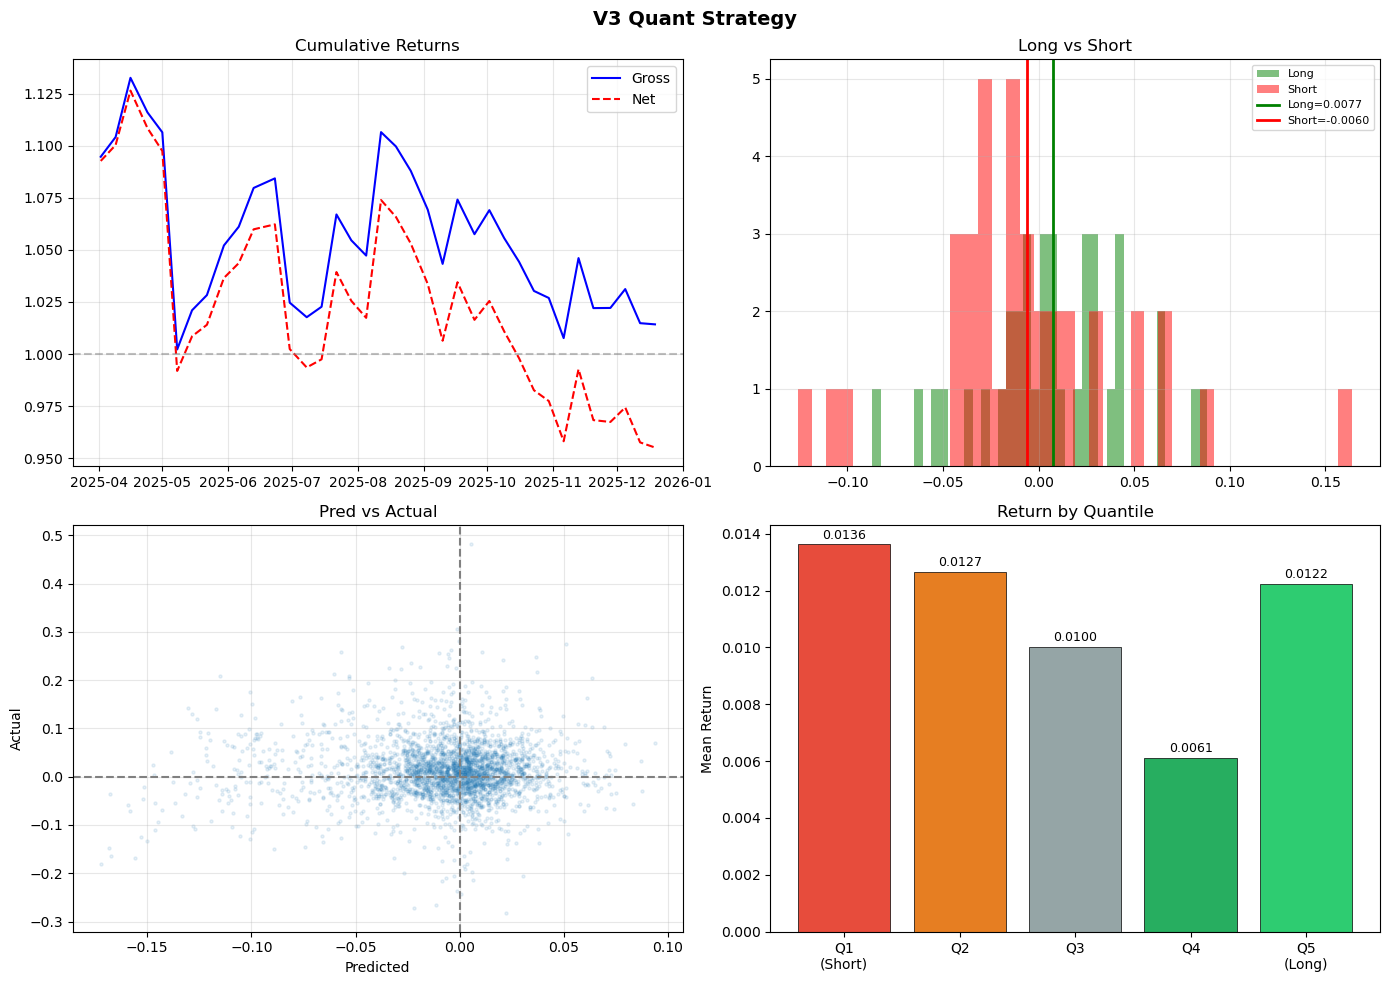

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('V3 Quant Strategy', fontsize=14, fontweight='bold')

ax = axes[0,0]
ax.plot(bt_final['date'], (1+bt_final['gross_return']).cumprod(), 'b-', label='Gross', lw=1.5)
ax.plot(bt_final['date'], (1+bt_final['net_return']).cumprod(), 'r--', label='Net', lw=1.5)
ax.axhline(y=1, color='gray', ls='--', alpha=0.5); ax.legend(); ax.set_title('Cumulative Returns'); ax.grid(True, alpha=0.3)

ax = axes[0,1]
ax.hist(bt_final['long_return'], bins=40, alpha=0.5, color='green', label='Long')
ax.hist(bt_final['short_return'], bins=40, alpha=0.5, color='red', label='Short')
ax.axvline(x=bt_final['long_return'].mean(), color='green', lw=2, label=f"Long={bt_final['long_return'].mean():.4f}")
ax.axvline(x=bt_final['short_return'].mean(), color='red', lw=2, label=f"Short={bt_final['short_return'].mean():.4f}")
ax.legend(fontsize=8); ax.set_title('Long vs Short'); ax.grid(True, alpha=0.3)

ax = axes[1,0]
s = res_final.sample(min(3000, len(res_final)))
ax.scatter(s['predicted'], s['actual'], alpha=0.1, s=5)
ax.axhline(y=0, color='gray', ls='--'); ax.axvline(x=0, color='gray', ls='--')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Pred vs Actual'); ax.grid(True, alpha=0.3)

ax = axes[1,1]
res_final['q'] = pd.qcut(res_final['predicted'], q=5, labels=['Q1\n(Short)','Q2','Q3','Q4','Q5\n(Long)'])
qr = res_final.groupby('q')['actual'].mean()
bars = ax.bar(qr.index, qr.values, color=['#e74c3c','#e67e22','#95a5a6','#27ae60','#2ecc71'], edgecolor='k', lw=0.5)
ax.axhline(y=0, color='k', ls='--', lw=0.5)
for b, v in zip(bars, qr.values): ax.text(b.get_x()+b.get_width()/2, v+0.0002, f'{v:.4f}', ha='center', fontsize=9)
ax.set_title('Return by Quantile'); ax.set_ylabel('Mean Return')

plt.tight_layout(); plt.savefig('v3_results.png', dpi=150); plt.show()

## 10. IC 分析

Mean IC: 0.0272 | IC Std: 0.1830 | IR: 0.1485 | IC>0: 59%
→ ❌ Near random


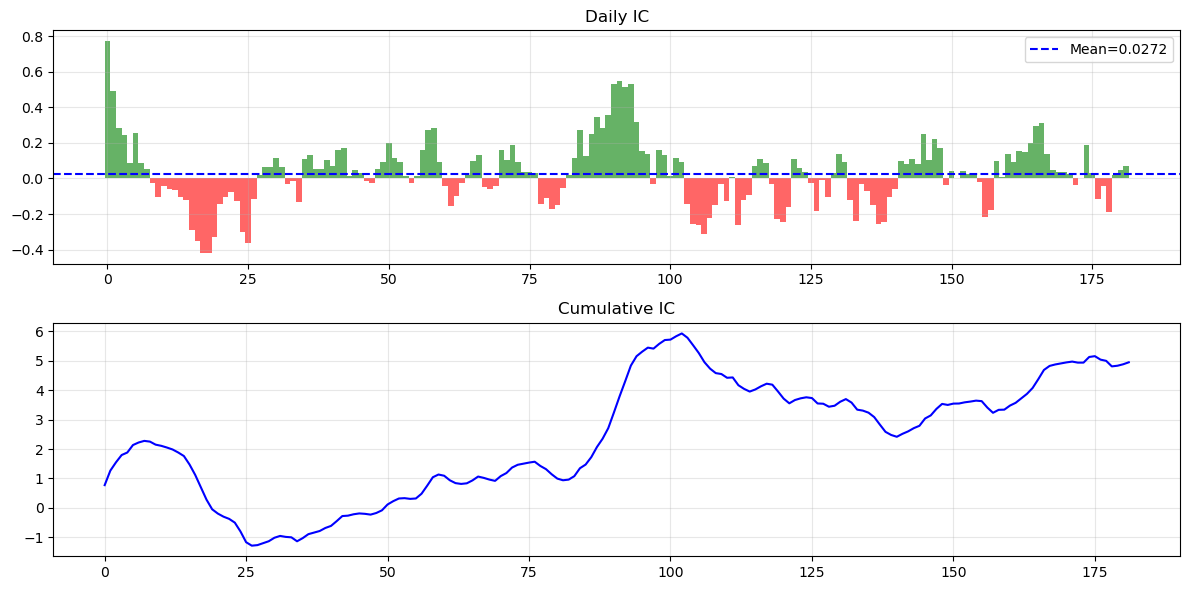

In [32]:
daily_ic = []
for dt, g in res_final.groupby('date'):
    if len(g) < 5: continue
    ic, _ = stats.spearmanr(g['predicted'], g['actual'])
    if not np.isnan(ic): daily_ic.append({'date': dt, 'ic': ic})

idf = pd.DataFrame(daily_ic).sort_values('date')
mic, sic = idf['ic'].mean(), idf['ic'].std()
ir = mic/sic if sic > 0 else 0

print(f'Mean IC: {mic:.4f} | IC Std: {sic:.4f} | IR: {ir:.4f} | IC>0: {(idf["ic"]>0).mean():.0%}')
if abs(mic) > 0.05: print('→ ✅ Good')
elif abs(mic) > 0.03: print('→ ⚠️ Weak')
else: print('→ ❌ Near random')

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6))
a1.bar(range(len(idf)), idf['ic'], color=['g' if x>0 else 'r' for x in idf['ic']], alpha=0.6, width=1)
a1.axhline(y=mic, color='blue', ls='--', label=f'Mean={mic:.4f}'); a1.legend(); a1.set_title('Daily IC'); a1.grid(True, alpha=0.3)
a2.plot(idf['ic'].cumsum().values, 'b-', lw=1.5); a2.set_title('Cumulative IC'); a2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

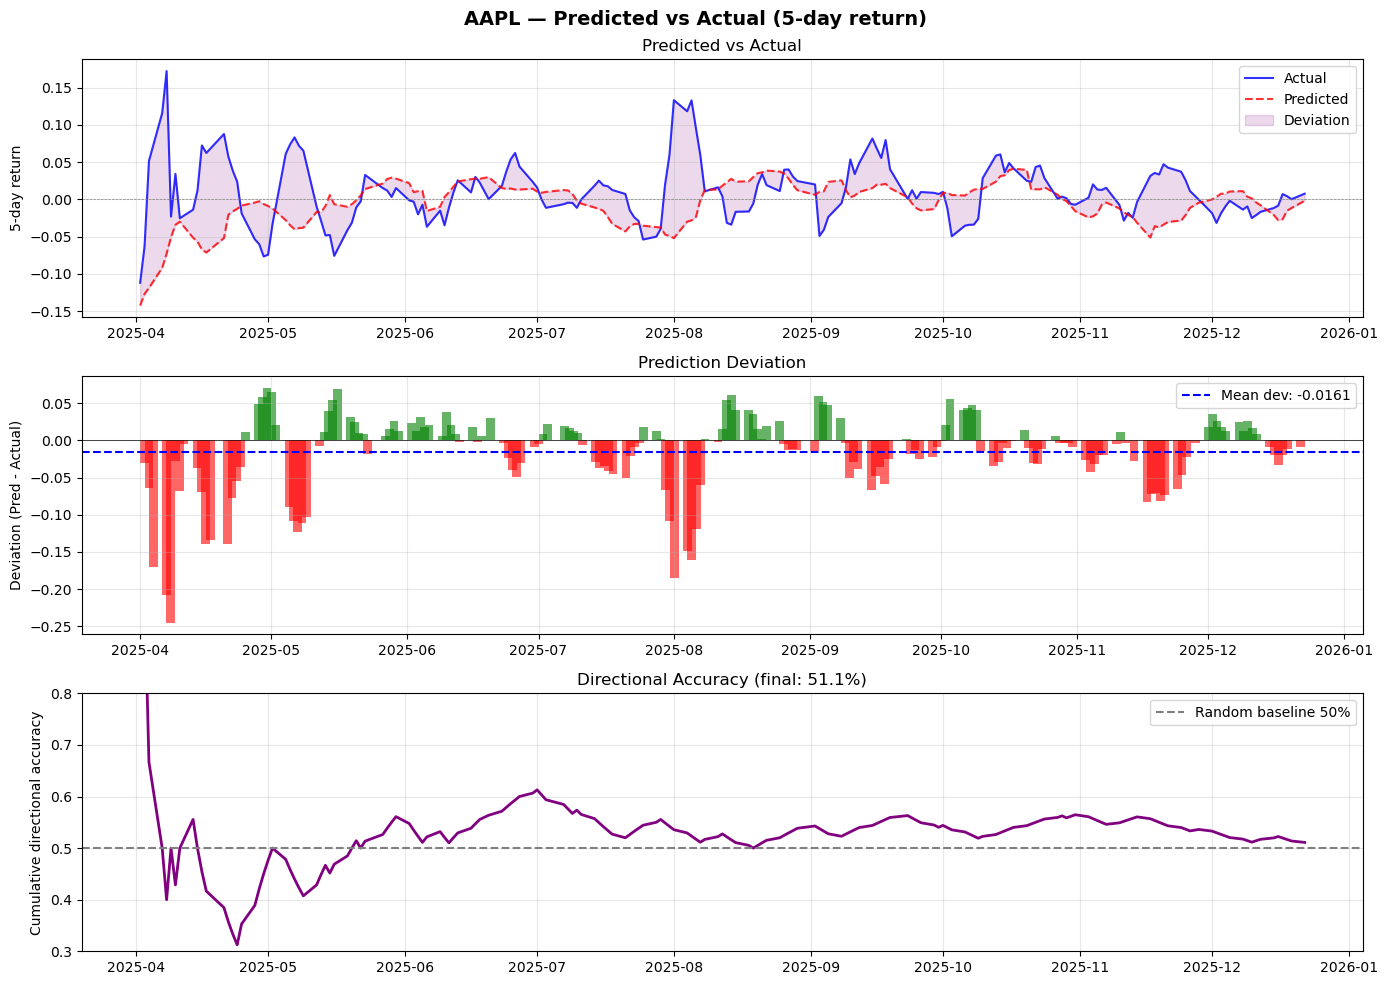


 AAPL Prediction Stats
  Samples:       182
  Date range:    2025-04-02 ~ 2025-12-22
  Mean dev:      -0.0161
  Dev std:       0.0524
  Direction acc: 51.1%
  Correlation:   -0.0659


In [35]:
def plot_stock_prediction(ticker, dataset, model, lookback=20):
    model.eval()
    
    mask = [i for i, t in enumerate(dataset['tickers_test']) if t == ticker]
    if len(mask) == 0:
        print(f"❌ {ticker} not in test set")
        print(f"Available: {sorted(set(dataset['tickers_test']))}")
        return
    
    dates = [dataset['dates_test'][i] for i in mask]
    actuals = dataset['y_test'][mask]
    
    X = torch.FloatTensor(dataset['X_test'][mask]).to(device)
    with torch.no_grad():
        preds = model(X).squeeze().cpu().numpy()
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f'{ticker} — Predicted vs Actual (5-day return)', fontsize=14, fontweight='bold')
    
    ax = axes[0]
    ax.plot(dates, actuals, 'b-', label='Actual', alpha=0.8, lw=1.5)
    ax.plot(dates, preds, 'r--', label='Predicted', alpha=0.8, lw=1.5)
    ax.axhline(y=0, color='gray', ls='--', lw=0.5)
    ax.fill_between(dates, actuals, preds, alpha=0.15, color='purple', label='Deviation')
    ax.legend(fontsize=10)
    ax.set_ylabel('5-day return')
    ax.set_title('Predicted vs Actual')
    ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    deviation = preds - actuals
    colors = ['green' if d >= 0 else 'red' for d in deviation]
    ax.bar(dates, deviation, color=colors, alpha=0.6, width=2)
    ax.axhline(y=0, color='black', lw=0.5)
    ax.axhline(y=deviation.mean(), color='blue', ls='--', label=f'Mean dev: {deviation.mean():.4f}')
    ax.legend()
    ax.set_ylabel('Deviation (Pred - Actual)')
    ax.set_title('Prediction Deviation')
    ax.grid(True, alpha=0.3)
    
    ax = axes[2]
    correct = (np.sign(preds) == np.sign(actuals)).astype(int)
    cum_accuracy = pd.Series(correct).expanding().mean()
    ax.plot(dates, cum_accuracy, 'purple', lw=2)
    ax.axhline(y=0.5, color='gray', ls='--', label='Random baseline 50%')
    ax.set_ylabel('Cumulative directional accuracy')
    ax.set_ylim(0.3, 0.8)
    ax.legend()
    ax.set_title(f'Directional Accuracy (final: {correct.mean():.1%})')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{ticker}_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n{'='*40}")
    print(f" {ticker} Prediction Stats")
    print(f"{'='*40}")
    print(f"  Samples:       {len(mask)}")
    print(f"  Date range:    {dates[0].strftime('%Y-%m-%d')} ~ {dates[-1].strftime('%Y-%m-%d')}")
    print(f"  Mean dev:      {deviation.mean():.4f}")
    print(f"  Dev std:       {deviation.std():.4f}")
    print(f"  Direction acc: {correct.mean():.1%}")
    print(f"  Correlation:   {np.corrcoef(preds, actuals)[0,1]:.4f}")

plot_stock_prediction('AAPL', dataset, model)

## 11. 可调参数

| 参数 | 位置 | 当前值 | 试试 |
|------|------|--------|------|
| `d_model` | Cell 4 | 192 | 128 / 256 |
| `num_layers` | Cell 4 | 4 | 2 / 6 |
| `nhead` | Cell 4 | 6 | 3 / 8 |
| `dropout` | Cell 4 | 0.15 | 0.1 / 0.25 |
| `rank/mse/ic weight` | Cell 5 | 0.5/0.2/0.3 | 0.7/0.1/0.2 |
| `NUM_EPOCHS` | Cell 6 | 80 | 60 / 120 |
| `T_max` | Cell 6 | 40 | 30 / 50 |
| `lr` | Cell 6 | 3e-4 | 1e-4 / 5e-4 |
| `TOP_N` | Cell 7 | 3 | 2 / 5 |
| `REBAL_FREQ` | Cell 7 | 5 | 3 / 10 |
| `train_ratio` | Cell 3 | 0.70 | 0.75 / 0.80 |